# Sinhala→English NMT Hallucination Detection

This notebook implements a **three-signal ensemble** for detecting hallucinations in neural machine translation (NMT) outputs, specifically for Sinhala→English translation. The pipeline combines:

- **mDeBERTa** — a fine-tuned token classifier that flags suspicious hypothesis tokens
- **Sequence log-probability** — the model's own uncertainty signal
- **LaBSE semantic similarity** — cross-lingual embedding cosine distance as a meaning-preservation check

The ensemble is evaluated across eight translation models from four different architectural families.

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Preprocessing](#2-data-loading--preprocessing)
3. [mDeBERTa Detector Training](#3-mdeberta-detector-training)
4. [Translation & Confidence Scoring](#4-translation--confidence-scoring)
5. [LaBSE Semantic Similarity](#5-labse-semantic-similarity)
6. [Main Evaluation Loop](#6-main-evaluation-loop)
7. [Ablation Study](#7-ablation-study)
8. [Error Analysis](#8-error-analysis)
9. [Statistical Analysis](#9-statistical-analysis)
10. [Results & Visualisations](#10-results--visualisations)
11. [Export](#11-export)


## 1. Environment Setup

Install and pin all dependencies, then restart the kernel so the new binaries are loaded cleanly. The `numpy<2.0` pin is required because `transformers 4.x` is not yet compatible with NumPy 2.


In [ ]:
# Uninstall existing torch/numpy to avoid stale binaries after version switch.
!pip uninstall -y torch torchvision torchaudio numpy

# Install the exact cu126 builds. Pinning versions keeps the run reproducible.
!pip install -q torch==2.9.0 torchvision==0.24.0 torchaudio==2.9.0 \
    --index-url https://download.pytorch.org/whl/cu126

# NMT dependencies. numpy<2.0 is pinned because transformers 4.x breaks on numpy 2.
!pip install -q transformers==4.57.1 "numpy<2.0" datasets accelerate sacremoses sentencepiece

# Kernel restart is needed so the newly installed binaries are actually loaded.
import os
os._exit(0)

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 186.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 197.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 200.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 75.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 104.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Imports & Device Selection

Load all libraries and detect whether a GPU is available. Everything downstream will use the `device` variable to move tensors to the right place.


In [ ]:
import torch
import gc
import re
import difflib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    default_data_collator
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

2026-04-01 04:16:26.325685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775016986.723373     138 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775016986.857329     138 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775016987.824209     138 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775016987.824287     138 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775016987.824295     138 computation_placer.cc:177] computation placer alr

Using device: cuda


### Version Check

A quick printout of exact library versions. Run this after every kernel restart to confirm the environment matches expectations.


In [ ]:
import sys
import torch
import re
import difflib
import numpy as np
import sklearn
import transformers

# Print exact versions so results can be reproduced on another machine.
print("--- ENVIRONMENT VERSIONS ---")
print(f"Python:       {sys.version.split()[0]}")
print(f"PyTorch:      {torch.__version__}")
print(f"NumPy:        {np.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"re:           {getattr(re, '__version__', 'Standard Library')}")
print(f"difflib:      Standard Library")
print("----------------------------")

--- ENVIRONMENT VERSIONS ---
Python:       3.12.12
PyTorch:      2.9.0+cu126
NumPy:        1.26.4
Scikit-Learn: 1.6.1
Transformers: 4.57.1
re:           2.2.1
difflib:      Standard Library
----------------------------


## 2. Data Loading & Preprocessing

Load the synthetic hallucination dataset, apply a two-stage cleaning pipeline, then split into training and evaluation sets.

The dataset has three columns per row: `sinhala` (source), `reference` (ground-truth translation), and `hypothesis` (NMT output to be evaluated).

**Filtering stages:**
1. Drop rows with null values in any of the three key columns.
2. Drop rows where the reference or hypothesis contains no Latin characters — these are usually encoding errors.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATASET_FILE = "/kaggle/input/datasets/navamobeysekara/final-synthetic/synthetic_hallucinations_exhaustive_balanced.csv"
print(f"Loading data from {DATASET_FILE}...")
df_raw = pd.read_csv(DATASET_FILE)

# Stage 1: remove rows missing any of the three key columns.
original_count = len(df_raw)
stage1 = df_raw.dropna(subset=["sinhala", "reference", "hypothesis"])
after_stage1 = len(stage1)

# Stage 2: drop rows where reference/hypothesis contain no Latin characters.
stage2 = stage1[
    stage1["reference"].str.contains("[a-zA-Z]", na=False) &
    stage1["hypothesis"].str.contains("[a-zA-Z]", na=False)
]
df_full = stage2.reset_index(drop=True)
after_stage2 = len(df_full)

print("── Data Filtering Report ──────────────────────────────────────")
print(f"  Rows loaded (raw):                  {original_count:>6}")
print(f"  Latin char filter:  {after_stage2:>6}  (dropped {after_stage1 - after_stage2})")
print(f"  Total rows dropped:                 {original_count - after_stage2:>6}  "
      f"({100*(original_count - after_stage2)/original_count:.1f}%)")
print("───────────────────────────────────────────────────────────────")

# Fix seed so every run produces the same eval dataset.
RANDOM_SEED = 42

train_df, eval_df = train_test_split(df_full, test_size=0.20, random_state=RANDOM_SEED)
eval_df = eval_df.reset_index(drop=True)

print(f"Training Samples:   {len(train_df)}")
print(f"Evaluation Samples: {len(eval_df)}")

Loading data from /kaggle/input/datasets/navamobeysekara/final-synthetic/synthetic_hallucinations_exhaustive_balanced.csv...
── Data Filtering Report ──────────────────────────────────────
  Rows loaded (raw):                   10008
  Latin char filter:   10005  (dropped 3)
  Total rows dropped:                      3  (0.0%)
───────────────────────────────────────────────────────────────
Training Samples:   8004
Evaluation Samples: 2001


## 3. mDeBERTa Detector Training

Fine-tune `microsoft/mdeberta-v3-base` as a **token-level binary classifier** — label 0 for normal tokens, label 1 for hallucinated tokens.

**How labels are assigned:**  
The hypothesis is aligned against the reference using `difflib.SequenceMatcher`. Inserted or replaced tokens get label 1, unless their character-level similarity to any reference word exceeds a semantic rescue threshold (0.80), in which case they're treated as valid paraphrases.

**Input format:**  
`[CLS] <sinhala_source> [SEP] <english_hypothesis> [SEP]`  
Loss is only computed on hypothesis tokens (source and special tokens use `-100`).


In [ ]:
import torch
import re
import difflib
import numpy as np
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    default_data_collator
)


class HallucinationDataset(Dataset):
    """
    Builds token-classification inputs for mDeBERTa.

    Each example is: [CLS] <sinhala_source> [SEP] <english_hypothesis> [SEP]
    Labels are 0 (normal) or 1 (hallucinated) on the hypothesis tokens;
    source tokens and special tokens are masked with -100 so the loss
    ignores them.
    """

    def __init__(self, dataframe, tokenizer, max_len=512):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def _normalize(self, text):
        # Add spaces around punctuation so it becomes its own token.
        return re.sub(r'([.,!?()])', r' \1 ', str(text)).strip().split()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        source    = str(row['sinhala']).strip()
        ref_words = self._normalize(row['reference'])
        hyp_words = self._normalize(row['hypothesis'])

        import difflib as _dl

        def _word_sim(a: str, b: str) -> float:
            """Character-level similarity in [0, 1]."""
            return _dl.SequenceMatcher(None, a.lower(), b.lower()).ratio()

        # Words that are close enough to any reference word are treated as
        # valid paraphrases rather than hallucinations.
        SEMANTIC_RESCUE_THRESHOLD = 0.80

        # Step 1: Align hypothesis against reference with SequenceMatcher.
        # Inserted/replaced spans are candidate hallucinations.
        word_labels = [0] * len(hyp_words)
        matcher = difflib.SequenceMatcher(None, ref_words, hyp_words)
        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            if tag in ['insert', 'replace']:
                for k in range(j1, j2):
                    if k < len(word_labels):
                        hyp_word = hyp_words[k]
                        best_sim = max(
                            (_word_sim(hyp_word, rw) for rw in ref_words),
                            default=0.0
                        )
                        word_labels[k] = 0 if best_sim >= SEMANTIC_RESCUE_THRESHOLD else 1

        # Step 2: Tokenize source text.
        src_tokens = self.tokenizer.tokenize(source)
        src_ids    = self.tokenizer.convert_tokens_to_ids(src_tokens)

        # Step 3: Tokenize hypothesis word-by-word.
        # Prepending a space makes SentencePiece treat each word as a
        # continuation rather than a sentence start.
        hyp_ids = []
        labels  = []
        for word, label in zip(hyp_words, word_labels):
            w_tokens = self.tokenizer.tokenize(" " + word)
            w_ids    = self.tokenizer.convert_tokens_to_ids(w_tokens)
            if w_ids:
                hyp_ids.extend(w_ids)
                # Propagate the word-level label to all its subword tokens.
                labels.extend([label] * len(w_ids))

        # Step 4: Build full sequence — [CLS] src [SEP] hyp [SEP].
        input_ids = (
            [self.tokenizer.cls_token_id]
            + src_ids
            + [self.tokenizer.sep_token_id]
            + hyp_ids
            + [self.tokenizer.sep_token_id]
        )

        # Step 5: Build labels — ignore everything before the hypothesis.
        final_labels = [-100] * (len(src_ids) + 2)  # CLS + src + SEP
        final_labels.extend(labels)
        final_labels.append(-100)  # final SEP

        # Step 6: Pad or truncate to max_len.
        if len(input_ids) > self.max_len:
            input_ids    = input_ids[:self.max_len]
            final_labels = final_labels[:self.max_len]
        else:
            pad_len       = self.max_len - len(input_ids)
            input_ids    += [self.tokenizer.pad_token_id] * pad_len
            final_labels += [-100] * pad_len

        return {
            "input_ids":      torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(
                [1 if i != self.tokenizer.pad_token_id else 0 for i in input_ids]
            ),
            "labels":         torch.tensor(final_labels, dtype=torch.long)
        }


def compute_metrics(p):
    """Flatten token predictions and compute token-level classification metrics."""
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Strip -100 (ignored) positions before scoring.
    true_predictions = [
        [p for (p, l) in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]
    true_labels = [
        [l for (p, l) in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]

    flat_preds  = [item for sublist in true_predictions for item in sublist]
    flat_labels = [item for sublist in true_labels      for item in sublist]

    if not flat_labels:
        return {"accuracy": 0.0, "f1": 0.0, "precision": 0.0, "recall": 0.0}

    return {
        "accuracy":  accuracy_score(flat_labels, flat_preds),
        "f1":        f1_score(flat_labels, flat_preds, average="binary", zero_division=0),
        "precision": precision_score(flat_labels, flat_preds, average="binary", zero_division=0),
        "recall":    recall_score(flat_labels, flat_preds, average="binary", zero_division=0),
    }


# Load the base checkpoint
model_checkpoint = "microsoft/mdeberta-v3-base"
tokenizer_det    = AutoTokenizer.from_pretrained(model_checkpoint)
model_det        = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint, num_labels=2
).to(device)

training_args = TrainingArguments(
    output_dir="./mdeberta_results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=True,        
    max_grad_norm=1.0,
    logging_steps=100
)

# Use 10% of the training data as a validation split.
train_sub_df, val_sub_df = tts(train_df, test_size=0.1, random_state=42)
train_sub_df = train_sub_df.reset_index(drop=True)
val_sub_df   = val_sub_df.reset_index(drop=True)

trainer_det = Trainer(
    model=model_det,
    args=training_args,
    train_dataset=HallucinationDataset(train_sub_df, tokenizer_det),
    eval_dataset=HallucinationDataset(val_sub_df,   tokenizer_det),
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

trainer_det.model_accepts_loss_kwargs = False

print("Starting mDeBERTa Training...")
trainer_det.train()
print("Training Complete.")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

...

Starting mDeBERTa Training...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.178800,0.221648,0.934131,0.631506,0.881783,0.491892
2,0.137400,0.159146,0.946908,0.743559,0.834005,0.670811
3,0.108600,0.184934,0.949079,0.747773,0.866192,0.657838
4,0.089000,0.168433,0.949885,0.761511,0.838752,0.697297
5,0.062100,0.197435,0.950381,0.758600,0.858607,0.679459
6,0.056200,0.204059,0.950381,0.758745,0.858117,0.680000


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

Training Complete.


### Save Detector

Persist the trained model and tokenizer so this cell can be skipped on subsequent runs.


In [ ]:
print("Training Complete.")

# Persist both the model weights and tokenizer config so they can be reloaded without retraining.
trainer_det.save_model("./mdeberta_detector")
tokenizer_det.save_pretrained("./mdeberta_detector")
print("Model saved to ./mdeberta_detector")

Training Complete.
Model saved to ./mdeberta_detector


## 4. Translation & Confidence Scoring

Define `safe_translate_score` — a single function that handles all eight model families. It returns:

- The translated string
- A **sequence log-probability** computed via teacher-forcing (the model's cross-entropy loss on its own output, negated and scaled by token count)

The teacher-forcing approach is used because extracting beam-search scores directly produces inconsistent tensor shapes across families.


In [ ]:
import torch
import numpy as np
from torch.nn.functional import log_softmax


def safe_translate_score(text, model, tokenizer, model_type="nllb"):
    """
    Translate `text` and return (translation, avg_log_prob).

    Confidence is computed via a separate teacher-forcing forward pass
    rather than extracting beam scores directly — beam-search score
    tensors have inconsistent shapes across model families.
    Returns ("", -999.0) on any error.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return "", -999.0

    try:
        # 1. Set source language and build inputs
        if "nllb" in model_type:
            tokenizer.src_lang = "sin_Sinh"
            inputs = tokenizer(text, return_tensors="pt").to(device)
            forced_bos_token_id = tokenizer.convert_tokens_to_ids("eng_Latn")

        elif "mBART50" in model_type or "ransaka" in model_type:
            tokenizer.src_lang = "si_LK"
            inputs = tokenizer(text, return_tensors="pt").to(device)
            forced_bos_token_id = tokenizer.lang_code_to_id["en_XX"]

        elif "m2m" in model_type:
            tokenizer.src_lang = "si"
            inputs = tokenizer(text, return_tensors="pt").to(device)
            forced_bos_token_id = tokenizer.get_lang_id("en")

        elif "mt5" in model_type:
            # mT5 fine-tunes don't use lang tokens — pass raw text.
            inputs = tokenizer(text, return_tensors="pt").to(device)
            forced_bos_token_id = None

        elif "ai4bharat" in model_type:
            tokenizer.src_lang = "sin_Sinh"
            tokenizer.tgt_lang = "eng_Latn"
            inputs = tokenizer(text, return_tensors="pt").to(device)
            forced_bos_token_id = tokenizer.lang_code_to_id["eng_Latn"]

        else:
            inputs = tokenizer(text, return_tensors="pt").to(device)
            forced_bos_token_id = None

        # 2. Generate translation
        gen_kwargs = {
            "max_length":    128,
            "num_beams":     4,
            "early_stopping": True
        }
        if forced_bos_token_id is not None:
            gen_kwargs["forced_bos_token_id"] = forced_bos_token_id

        with torch.no_grad():
            generated_tokens = model.generate(**inputs, **gen_kwargs)

        translation = tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

        # 3. Compute confidence via teacher-forcing 
        # Feed the generated output back as labels to get the model's
        # cross-entropy loss, then negate it (higher = more confident).
        with torch.no_grad():
            labels = generated_tokens.clone()
            labels[labels == tokenizer.pad_token_id] = -100
            outputs        = model(**inputs, labels=labels)
            confidence_score = -outputs.loss.item()

        return translation, confidence_score

    except Exception as e:
        print(f"Error processing '{text[:20]}...': {e}")
        return "", -999.0

### GPU Memory Check

Free up CUDA memory before loading the translation models. With mDeBERTa already resident, this step is important to avoid OOM errors when loading the larger models like NLLB 1.3B.


In [ ]:
import gc
import torch

# Free up memory before loading the translation models.
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")
print(f"Free:      {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.2f} GB")

Allocated: 3.38 GB
Reserved:  3.78 GB
Free:      12.26 GB


## 5. LaBSE Semantic Similarity

Load `sentence-transformers/LaBSE` once, before the main evaluation loop. LaBSE produces language-agnostic embeddings, making it well-suited for cross-lingual similarity between a Sinhala source and its English hypothesis.

The embedding function uses mean pooling over non-padding tokens followed by L2 normalisation.


In [ ]:
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

# LaBSE is loaded once here and reused in the main evaluation loop.
print("Loading LaBSE model...")
tokenizer_labse = AutoTokenizer.from_pretrained("sentence-transformers/LaBSE")
model_labse     = AutoModel.from_pretrained("sentence-transformers/LaBSE").to(device)
model_labse.eval()
print("LaBSE ready.")


def get_embeddings_transformers(texts, batch_size=16):
    """
    Encode a list of strings with LaBSE and return L2-normalised embeddings.
    Uses mean pooling over non-padding tokens.
    """
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="LaBSE embeddings"):
        batch_texts   = texts[i:i+batch_size]
        encoded_input = tokenizer_labse(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt',
            max_length=512
        ).to(device)
        with torch.no_grad():
            model_output = model_labse(**encoded_input)

        # Mean-pool over the token dimension, ignoring padding.
        attention_mask     = encoded_input['attention_mask']
        token_embeddings   = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings     = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask           = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        embeddings         = sum_embeddings / sum_mask
        embeddings         = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        all_embeddings.extend(embeddings.cpu().numpy())
    return all_embeddings

Loading LaBSE model...


tokenizer_config.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

LaBSE ready.


## 6. Main Evaluation Loop

The core of the pipeline. For each model in the registry:

1. **Translate** all evaluation sentences and collect sequence log-probs
2. **Run mDeBERTa** to get a per-sentence token-risk rate
3. **Compute LaBSE** cosine similarity between source and hypothesis
4. **Compute binary flags** for all seven detection combinations (each signal alone, pairs, all three)
5. **Compute the ensemble score** — a weighted sum of the three normalised signals
6. **Log a leaderboard row** with aggregate counts

The model is deleted from GPU after each iteration to make room for the next one.


In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    M2M100ForConditionalGeneration,
    T5ForConditionalGeneration, T5Tokenizer,
    MarianMTModel, MarianTokenizer,
)
import torch
import numpy as np
from tqdm.auto import tqdm

# Ensemble hyper-parameters
# These weights were chosen via the ablation study in Section 3.8.
LOGPROB_PERCENTILE   = 30.0  
RISK_THRESHOLD       = 0.20  
LOGPROB_WEIGHT       = 0.3
MDEBERTA_WEIGHT      = 0.5
LABSE_WEIGHT         = 0.2
LABSE_RISK_THRESHOLD = 0.20  # 1 - cosine_similarity threshold
ENSEMBLE_THRESHOLD   = 0.40  # final score above this → hallucination flag

# Preview the τ sensitivity sweep. Actual numbers are printed after the main loop.
print("── Risk Threshold (τ) Sensitivity Preview ──────────────────────")
print("  (Uses mDeBERTa risk scores from a previous run if available,")
print("   otherwise re-evaluated after the main loop below.)")
THRESHOLD_SWEEP = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
print(f"  Thresholds to sweep: {THRESHOLD_SWEEP}")
print("  Results will be printed in the post-loop analysis cell.")
print("────────────────────────────────────────────────────────────────")

# Model registry 
# Format: "short_name": ("hf_path", "family")
#
# Family controls how the tokenizer's source language is set and which
# forced-BOS token is injected at generation time:
#   nllb    – NllbTokenizer,    forced_bos = convert_tokens_to_ids("eng_Latn")
#   mbart   – MBartTokenizer,   src="si_LK",  forced_bos="en_XX"
#   m2m     – M2M100Tokenizer,  src="si",     forced_bos="en"
#   mt5     – plain AutoTokenizer, no lang tokens
#   madlad  – T5ForConditionalGeneration, prepend "<2en> " to source
#   marian  – MarianMTModel,    prepend ">>en<< " to source

models_to_test = {
    # Original four models from the paper
    "nllb_600m":  ("facebook/nllb-200-distilled-600M",         "nllb"),
    "m2m_1.2b":   ("facebook/m2m100_1.2B",                     "m2m"),
    "mt5_sin":    ("thilina/mt5-sinhalese-english",             "mt5"),
    "mBART50":    ("facebook/mbart-large-50-many-to-many-mmt",  "mbart"),

    # NLLB size ablation
    "nllb_1.3b":  ("facebook/nllb-200-distilled-1.3B",         "nllb"),

    # Architectural diversity
    # Helsinki Marian: lightweight multilingual→EN
    "opus_mul_en": ("Helsinki-NLP/opus-mt-mul-en",              "marian"),

    # Smaller M2M sibling for family comparison
    "m2m_418m":   ("facebook/m2m100_418M",                     "m2m"),

    # mBART many-to-ONE (dedicated →EN fine-tune vs many-to-many above)
    "mbart_m2o":  ("facebook/mbart-large-50-many-to-one-mmt",  "mbart"),
}


def load_model(model_path, family):
    if family == "madlad":
        tok = T5Tokenizer.from_pretrained(model_path)
        mdl = T5ForConditionalGeneration.from_pretrained(model_path).to(device)
    elif family == "marian":
        tok = MarianTokenizer.from_pretrained(model_path)
        mdl = MarianMTModel.from_pretrained(model_path).to(device)
    elif family == "m2m":
        tok = AutoTokenizer.from_pretrained(model_path)
        mdl = M2M100ForConditionalGeneration.from_pretrained(model_path).to(device)
    else:
        tok = AutoTokenizer.from_pretrained(model_path)
        mdl = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
    return tok, mdl


def safe_translate_score(text, model, tokenizer, family):
    """
    Translate `text` and return (translation_str, avg_log_prob).

    Log-prob is scaled by sequence length so longer outputs don't get
    an unfair penalty. Returns -999.0 on error.
    """
    try:
        with torch.no_grad():
            # Prepare inputs per family 
            if family == "nllb":
                tokenizer.src_lang = "sin_Sinh"
                inputs    = tokenizer(text, return_tensors="pt",
                                      truncation=True, max_length=512).to(device)
                forced_bos = tokenizer.convert_tokens_to_ids("eng_Latn")
                gen_ids   = model.generate(**inputs,
                                           forced_bos_token_id=forced_bos,
                                           max_new_tokens=256)

            elif family == "mbart":
                tokenizer.src_lang = "si_LK"
                inputs    = tokenizer(text, return_tensors="pt",
                                      truncation=True, max_length=512).to(device)
                forced_bos = tokenizer.lang_code_to_id["en_XX"]
                gen_ids   = model.generate(**inputs,
                                           forced_bos_token_id=forced_bos,
                                           max_new_tokens=256)

            elif family == "m2m":
                tokenizer.src_lang = "si"
                inputs    = tokenizer(text, return_tensors="pt",
                                      truncation=True, max_length=512).to(device)
                forced_bos = tokenizer.get_lang_id("en")
                gen_ids   = model.generate(**inputs,
                                           forced_bos_token_id=forced_bos,
                                           max_new_tokens=256)

            elif family == "mt5":
                inputs  = tokenizer(text, return_tensors="pt",
                                    truncation=True, max_length=512).to(device)
                gen_ids = model.generate(**inputs, max_new_tokens=256)

            elif family == "madlad":
                # MADLAD uses a "<2en> " prefix to specify the target language.
                inputs  = tokenizer(f"<2en> {text}", return_tensors="pt",
                                    truncation=True, max_length=512).to(device)
                gen_ids = model.generate(**inputs, max_new_tokens=256)

            elif family == "marian":
                # Marian multilingual models use ">>en<< " as the target tag.
                inputs  = tokenizer(f">>en<< {text}", return_tensors="pt",
                                    truncation=True, max_length=512).to(device)
                gen_ids = model.generate(**inputs, max_new_tokens=256)

            else:
                return "[unknown family]", -999.0

            # Decode 
            translation = tokenizer.decode(gen_ids[0], skip_special_tokens=True)

            # Compute sequence log-prob via teacher-forcing 
            labels = gen_ids.clone()
            labels[labels == tokenizer.pad_token_id] = -100
            out = model(**inputs, labels=labels)

            # Scale by active token count to avoid penalising long outputs.
            num_active = max((labels != -100).sum().item(), 1)
            log_prob   = -out.loss.item() * num_active

        return translation, log_prob

    except Exception as e:
        print(f"  [WARN] Translation error ({family}): {e}")
        return "[ERROR]", -999.0


# Main evaluation loop 
results_log  = []
eval_df_run  = eval_df.copy()

print(f"Evaluating {len(eval_df_run)} rows across {len(models_to_test)} models...\n")

for model_name, (model_path, family) in models_to_test.items():
    print(f"\n{'='*60}")
    print(f"  Model : {model_name}  ({family})")
    print(f"  Path  : {model_path}")
    print(f"{'='*60}")

    # A. Load model
    tokenizer_mt, model_mt = load_model(model_path, family)

    # B. Translate and collect log-probs
    translations, log_probs = [], []
    batch_size    = 16
    sinhala_texts = eval_df_run['sinhala'].tolist()

    for i in tqdm(range(0, len(sinhala_texts), batch_size),
                  desc=f"Translating ({model_name})"):
        batch_texts   = sinhala_texts[i:i+batch_size]
        batch_results = [
            safe_translate_score(text, model_mt, tokenizer_mt, family)
            for text in batch_texts
        ]
        for trans, lp in batch_results:
            translations.append(trans)
            log_probs.append(lp)

    col_hyp  = f'hyp_{model_name}'
    col_conf = f'conf_{model_name}'
    eval_df_run[col_hyp]  = translations
    eval_df_run[col_conf] = log_probs

    # Free GPU memory before loading the next model.
    del model_mt, tokenizer_mt
    torch.cuda.empty_cache()

    # C. mDeBERTa hallucination detection
    # Encode (source, hypothesis) pairs and extract per-token risk scores.
    detector_inputs = []
    for src, hyp in zip(eval_df_run['sinhala'], eval_df_run[col_hyp]):
        enc = tokenizer_det(
            src, hyp,
            truncation=True, padding='max_length',
            max_length=512, return_tensors="pt"
        )
        detector_inputs.append(enc['input_ids'].squeeze(0))

    batch_size, all_preds = 16, []
    input_tensor = torch.stack(detector_inputs)
    for i in range(0, len(input_tensor), batch_size):
        batch  = input_tensor[i:i+batch_size].to(device)
        with torch.no_grad():
            logits = model_det(input_ids=batch).logits
        all_preds.extend(torch.argmax(logits, dim=2).cpu().numpy())

    # Compute risk rate = fraction of hypothesis tokens predicted as label 1.
    risk_rates = []
    for i, seq in enumerate(all_preds):
        id_seq      = detector_inputs[i].tolist()
        sep_indices = [idx for idx, v in enumerate(id_seq)
                       if v == tokenizer_det.sep_token_id]
        rate = (
            float(np.mean(seq[sep_indices[0]+1 : sep_indices[1]] == 1))
            if len(sep_indices) >= 2 else 0.0
        )
        risk_rates.append(rate)

    col_risk = f'risk_{model_name}'
    eval_df_run[col_risk] = risk_rates

    # D. LaBSE semantic similarity
    # Embed source and hypothesis, then take cosine similarity as a
    # cross-lingual meaning-preservation score.
    sinhala_texts_batch = eval_df_run['sinhala'].astype(str).tolist()
    hyp_texts_batch     = eval_df_run[col_hyp].astype(str).tolist()

    src_embs   = get_embeddings_transformers(sinhala_texts_batch)
    hyp_embs   = get_embeddings_transformers(hyp_texts_batch)
    labse_sims = [
        cosine_similarity([s], [h])[0][0]
        for s, h in zip(src_embs, hyp_embs)
    ]

    col_labse = f'labse_sim_{model_name}'
    eval_df_run[col_labse] = labse_sims
    labse_risk = 1 - eval_df_run[col_labse]

    # E. Binary flags per detection method
    valid_mask = eval_df_run[col_conf] > -900
    lps        = eval_df_run.loc[valid_mask, col_conf]
    lp_thresh  = float(np.percentile(lps, LOGPROB_PERCENTILE))
    eval_df_run[f'lp_threshold_{model_name}'] = lp_thresh

    flag_model   = eval_df_run[col_risk] > RISK_THRESHOLD
    flag_logprob = valid_mask & (eval_df_run[col_conf] < lp_thresh)
    flag_labse   = labse_risk > LABSE_RISK_THRESHOLD

    eval_df_run[f'flag_all_three_{model_name}']  = (flag_model & flag_logprob & flag_labse).astype(int)
    eval_df_run[f'flag_mDeB_LP_{model_name}']    = (flag_model & flag_logprob & ~flag_labse).astype(int)
    eval_df_run[f'flag_mDeB_LaBSE_{model_name}'] = (flag_model & ~flag_logprob & flag_labse).astype(int)
    eval_df_run[f'flag_LP_LaBSE_{model_name}']   = (~flag_model & flag_logprob & flag_labse).astype(int)
    eval_df_run[f'flag_model_only_{model_name}'] = (flag_model & ~flag_logprob & ~flag_labse).astype(int)
    eval_df_run[f'flag_lp_only_{model_name}']    = (~flag_model & flag_logprob & ~flag_labse).astype(int)
    eval_df_run[f'flag_labse_only_{model_name}'] = (~flag_model & ~flag_logprob & flag_labse).astype(int)
    eval_df_run[f'flag_none_{model_name}']       = (~flag_model & ~flag_logprob & ~flag_labse).astype(int)

    # F. Weighted ensemble score
    # Normalise log-prob to [0, 1] where 1 = low confidence.
    norm_lp = 1 - (lps - lps.min()) / (lps.max() - lps.min() + 1e-9)
    eval_df_run.loc[valid_mask, f'ensemble_score_{model_name}'] = (
        MDEBERTA_WEIGHT * eval_df_run.loc[valid_mask, col_risk]
        + LOGPROB_WEIGHT * norm_lp
        + LABSE_WEIGHT   * labse_risk[valid_mask]
    )
    # Fall back to raw risk score for rows with invalid log-prob.
    eval_df_run[f'ensemble_score_{model_name}'] = (
        eval_df_run[f'ensemble_score_{model_name}']
        .fillna(eval_df_run[col_risk])
    )

    # G. Log a summary row for the leaderboard
    results_log.append({
        "Model":              model_name,
        "Avg Log Prob":       lps.mean(),
        "LogProb Thresh":     lp_thresh,
        "All Three":          int(eval_df_run[f'flag_all_three_{model_name}'].sum()),
        "mDeBERTa + LogProb": int(eval_df_run[f'flag_mDeB_LP_{model_name}'].sum()),
        "mDeBERTa + LaBSE":   int(eval_df_run[f'flag_mDeB_LaBSE_{model_name}'].sum()),
        "LogProb + LaBSE":    int(eval_df_run[f'flag_LP_LaBSE_{model_name}'].sum()),
        "mDeBERTa Only":      int(eval_df_run[f'flag_model_only_{model_name}'].sum()),
        "LogProb Only":       int(eval_df_run[f'flag_lp_only_{model_name}'].sum()),
        "LaBSE Only":         int(eval_df_run[f'flag_labse_only_{model_name}'].sum()),
        "None":               int(eval_df_run[f'flag_none_{model_name}'].sum()),
    })
    print(f"  Done. Avg log-prob: {results_log[-1]['Avg Log Prob']:.3f}")

print("\n\nEvaluation Complete.")
results_df = pd.DataFrame(results_log)
display(results_df)

── Risk Threshold (τ) Sensitivity Preview ──────────────────────
  (Uses mDeBERTa risk scores from a previous run if available,
   otherwise re-evaluated after the main loop below.)
  Thresholds to sweep: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
  Results will be printed in the post-loop analysis cell.
────────────────────────────────────────────────────────────────
Evaluating 2001 rows across 8 models...


  Model : nllb_600m  (nllb)
  Path  : facebook/nllb-200-distilled-600M


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

LaBSE embeddings:   0%|          | 0/126 [00:00<?, ?it/s]

LaBSE embeddings:   0%|          | 0/126 [00:00<?, ?it/s]

  Done. Avg log-prob: -18.640


Evaluation Complete.


/tmp/ipykernel_138/3479622712.py:245: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eval_df_run[col_labse] = labse_sims
/tmp/ipykernel_138/3479622712.py:252: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eval_df_run[f'lp_threshold_{model_name}'] = lp_thresh
/tmp/ipykernel_138/3479622712.py:258: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmente

,Model,Avg Log Prob,LogProb Thresh,All Three,mDeBERTa + LogProb,mDeBERTa + LaBSE,LogProb + LaBSE,mDeBERTa Only,LogProb Only,LaBSE Only,None
0,nllb_600m,-20.755089,-21.828222,19,95,12,11,185,474,19,1186
1,m2m_1.2b,-26.039945,-27.244495,34,81,21,22,178,463,38,1164
2,mt5_sin,-16.539746,-17.358042,284,132,141,56,245,127,97,919
3,mBART50,-18.695066,-19.985490,14,90,13,12,172,484,25,1191
4,nllb_1.3b,-21.627827,-22.769100,23,102,27,15,195,460,30,1149
5,opus_mul_en,-410.018352,-499.348899,97,58,232,61,184,292,390,687
6,m2m_418m,-25.829798,-27.471092,42,103,34,46,143,408,70,1155
7,mbart_m2o,-18.639900,-19.786128,11,88,18,8,198,493,22,1163


## 7. Ablation Study — Ensemble Weights

Compare five weight configurations (detector-heavy, log-prob-heavy, semantic-heavy, uniform, and the chosen mix) on precision, recall, F1, and flagging rate.

The chosen weights `(w_det=0.5, w_lp=0.3, w_sem=0.2)` were selected based on this analysis.


SECTION 3.8 – ENSEMBLE WEIGHT ABLATION SUMMARY
  Classification threshold : 0.4
  Models evaluated         : 8
                         Weights  w_det  w_lp  w_sem  Precision  Recall    F1  Flag Rate (%)
  A: Det-Mild\n(0.5 / 0.3 / 0.2)  0.500 0.300  0.200      0.480   0.056 0.098          5.816
 B: Det-Heavy\n(0.7 / 0.2 / 0.1)  0.700 0.200  0.100      0.486   0.081 0.134          8.452
  C: LP-Heavy\n(0.2 / 0.6 / 0.2)  0.200 0.600  0.200      0.438   0.017 0.032          2.055
 D: Sem-Heavy\n(0.2 / 0.2 / 0.6)  0.200 0.200  0.600      0.451   0.032 0.059          3.486
E: Uniform\n(0.33 / 0.33 / 0.33)  0.333 0.333  0.333      0.451   0.032 0.059          3.486

► Chosen weights F1     : 0.098
► Best F1 configuration : B: Det-Heavy
(0.7 / 0.2 / 0.1)


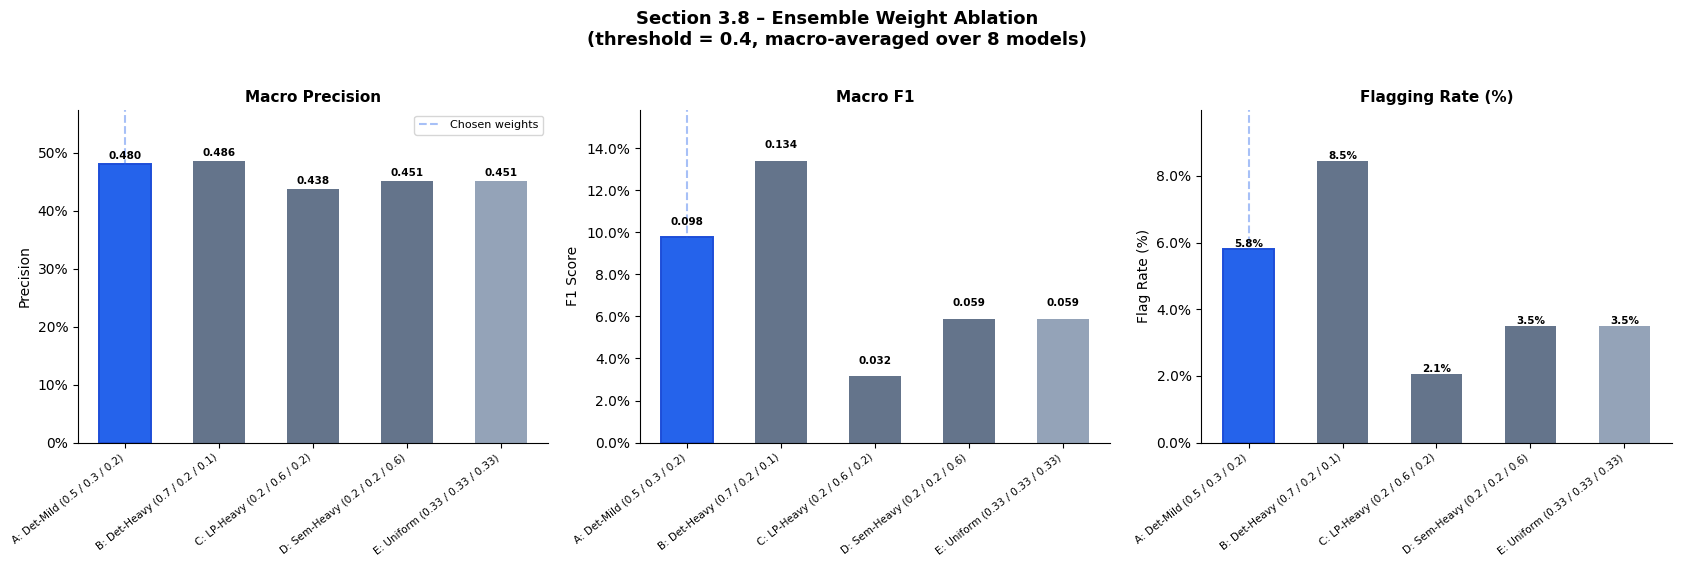

Figure saved to section_3_8_weight_ablation.png


In [ ]:
# Ensemble Weight Ablation 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import precision_score, recall_score, f1_score
from itertools import product

# Classification threshold for the ablation — a sentence is flagged if
# its ensemble score meets or exceeds this value.
ENSEMBLE_THRESHOLD = 0.40
MODEL_KEYS         = list(models_to_test.keys())


def normalise_conf(series):
    """
    Map seq-log-prob (negative, lower = worse) to a [0, 1] suspicion score.
    0 = very confident, 1 = very suspicious.
    """
    s = series.copy().clip(upper=0)  # perfect confidence is capped at 0
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(np.zeros(len(s)), index=series.index)
    return (s - hi) / (lo - hi)  # hi → 0 (good), lo → 1 (bad)


for m in MODEL_KEYS:
    conf_col = f"conf_{m}"
    if conf_col in eval_df_run.columns:
        eval_df_run[f"conf_norm_{m}"] = normalise_conf(
            eval_df_run[conf_col]
            .replace(-999, np.nan)
            .fillna(eval_df_run[conf_col].median())
        )


WEIGHT_CANDIDATES = {
    "A: Det-Mild\n(0.5 / 0.3 / 0.2)":    (0.5, 0.3, 0.2),
    "B: Det-Heavy\n(0.7 / 0.2 / 0.1)":  (0.7, 0.2, 0.1),
    "C: LP-Heavy\n(0.2 / 0.6 / 0.2)":   (0.2, 0.6, 0.2),
    "D: Sem-Heavy\n(0.2 / 0.2 / 0.6)":  (0.2, 0.2, 0.6),
    "E: Uniform\n(0.33 / 0.33 / 0.33)": (1/3, 1/3, 1/3),
}


def evaluate_weights(df, w_det, w_lp, w_sem, model_keys, threshold):
    """Return macro-averaged metrics for a given weight triple."""
    rows = []
    for m in model_keys:
        risk_col  = f"risk_{m}"
        conf_col  = f"conf_norm_{m}"
        labse_col = f"labse_risk_{m}"

        if not all(c in df.columns for c in [risk_col, conf_col, "label"]):
            continue

        det_score = df[risk_col].fillna(0)
        lp_score  = df[conf_col].fillna(0)

        if labse_col in df.columns:
            sem_score = df[labse_col].fillna(0)
        else:
            total = w_det + w_lp
            if total == 0:
                sem_score = pd.Series(np.zeros(len(df)), index=df.index)
            else:
                factor    = (w_det + w_lp + w_sem) / total
                w_det     = w_det * factor
                w_lp      = w_lp  * factor
                w_sem     = 0.0
                sem_score = pd.Series(np.zeros(len(df)), index=df.index)

        ensemble = w_det * det_score + w_lp * lp_score + w_sem * sem_score
        y_pred   = (ensemble >= threshold).astype(int)
        y_true   = df["label"].astype(int)

        rows.append({
            "model":     m,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall":    recall_score(y_true, y_pred, zero_division=0),
            "f1":        f1_score(y_true, y_pred, zero_division=0),
            "flag_rate": y_pred.mean() * 100,
        })

    if not rows:
        return None

    res   = pd.DataFrame(rows)
    macro = res[["precision", "recall", "f1", "flag_rate"]].mean().rename(
        lambda c: f"macro_{c}"
    )
    return macro


# Evaluate all candidates
ablation_rows = []
for label, (w_det, w_lp, w_sem) in WEIGHT_CANDIDATES.items():
    metrics = evaluate_weights(
        eval_df_run, w_det, w_lp, w_sem, MODEL_KEYS, ENSEMBLE_THRESHOLD
    )
    if metrics is not None:
        row = {"Weights": label, "w_det": w_det, "w_lp": w_lp, "w_sem": w_sem}
        row.update(metrics.to_dict())
        ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)

# Print summary table 
print("=" * 75)
print("SECTION 3.8 – ENSEMBLE WEIGHT ABLATION SUMMARY")
print(f"  Classification threshold : {ENSEMBLE_THRESHOLD}")
print(f"  Models evaluated         : {len(MODEL_KEYS)}")
print("=" * 75)

display_cols = ["Weights", "w_det", "w_lp", "w_sem",
                "macro_precision", "macro_recall", "macro_f1", "macro_flag_rate"]
print(
    ablation_df[display_cols]
    .rename(columns={
        "macro_precision": "Precision",
        "macro_recall":    "Recall",
        "macro_f1":        "F1",
        "macro_flag_rate": "Flag Rate (%)",
    })
    .to_string(index=False, float_format="{:.3f}".format)
)

chosen_label  = "A: Det-Mild\n(0.5 / 0.3 / 0.2)"
best_f1_label = ablation_df.loc[ablation_df["macro_f1"].idxmax(), "Weights"]
print(f"\n► Chosen weights F1     : {ablation_df.loc[ablation_df['Weights']==chosen_label, 'macro_f1'].values[0]:.3f}")
print(f"► Best F1 configuration : {best_f1_label.strip()}")

# Visualise 
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle(
    "Section 3.8 – Ensemble Weight Ablation\n"
    f"(threshold = {ENSEMBLE_THRESHOLD}, macro-averaged over {len(MODEL_KEYS)} models)",
    fontsize=13, fontweight="bold", y=1.02
)

COLORS = [
    "#2563EB",  
    "#64748B", "#64748B", "#64748B", 
    "#94A3B8", 
]
EDGE  = ["#1D4ED8"] + ["none"] * 4

weight_labels = [w.replace("\n", " ") for w in ablation_df["Weights"]]
x     = np.arange(len(weight_labels))
bar_w = 0.55

for ax, (metric, ylabel, title) in zip(
    axes,
    [
        ("macro_precision", "Precision",    "Macro Precision"),
        ("macro_f1",        "F1 Score",     "Macro F1"),
        ("macro_flag_rate", "Flag Rate (%)", "Flagging Rate (%)"),
    ],
):
    vals = ablation_df[metric].values
    bars = ax.bar(x, vals, width=bar_w, color=COLORS, edgecolor=EDGE, linewidth=1.4)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{v:.3f}" if metric != "macro_flag_rate" else f"{v:.1f}%",
            ha="center", va="bottom", fontsize=7.5, fontweight="bold"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(weight_labels, rotation=38, ha="right", fontsize=7.5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(1.0) if metric != "macro_flag_rate"
        else mticker.FormatStrFormatter("%.1f%%")
    )
    ax.set_ylim(0, max(vals) * 1.18)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axvline(0, color="#2563EB", linewidth=1.5, linestyle="--",
               alpha=0.4, label="Chosen weights")

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("section_3_8_weight_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to section_3_8_weight_ablation.png")


## 8. Error Analysis

Two functions for digging into model-specific behaviour:

- `analyze_worst_hallucinations` — top-N most suspicious outputs per detection method, useful for qualitative review
- `analyze_false_positives` — cases where mDeBERTa flagged a sentence but LaBSE confirmed the meaning was preserved, which are likely surface-level false alarms


In [15]:
def analyze_worst_hallucinations(df, model_name, top_n=10):
    """
    Show the top-N most suspicious outputs according to each detection method,
    plus the ensemble's overall top picks.
    """
    print(f"\n{'='*30} Top {top_n} Analysis for {model_name} {'='*30}")

    col_risk     = f'risk_{model_name}'
    col_conf     = f'conf_{model_name}'
    col_labse    = f'labse_sim_{model_name}'
    col_ensemble = f'ensemble_score_{model_name}'
    col_hyp      = f'hyp_{model_name}'

    # Top flagged by each individual signal
    top_risk     = df.sort_values(by=col_risk,     ascending=False).head(top_n)
    top_uncertain = df.sort_values(by=col_conf,    ascending=True).head(top_n)
    top_labse    = df.sort_values(by=col_labse,    ascending=True).head(top_n)
    top_ensemble = df.sort_values(by=col_ensemble, ascending=False).head(top_n)

    print("\n[METHOD A] Highest mDeBERTa risk (learned token patterns):")
    display(top_risk[['sinhala', 'reference', col_hyp, col_risk, col_conf, col_labse]])

    print("\n[METHOD B] Lowest model confidence (seq log-probability):")
    display(top_uncertain[['sinhala', 'reference', col_hyp, col_conf, col_risk, col_labse]])

    print("\n[METHOD C] Highest LaBSE risk (lowest cross-lingual similarity):")
    display(top_labse[['sinhala', 'reference', col_hyp, col_labse, col_risk, col_conf]])

    print("\n[ENSEMBLE] Highest combined suspicion (all three signals):")
    display(top_ensemble[['sinhala', 'reference', col_hyp, col_ensemble]])


def analyze_false_positives(df, model_name, top_n=10,
                            risk_thresh=0.20, labse_thresh=0.75):
    """
    Surface likely false positives: cases where mDeBERTa raised a flag
    but LaBSE says the meaning is still intact.

    A high mDeBERTa risk paired with high LaBSE similarity suggests the
    model spotted surface-level differences that don't actually affect meaning.
    """
    col_risk  = f'risk_{model_name}'
    col_labse = f'labse_sim_{model_name}'
    col_conf  = f'conf_{model_name}'
    col_hyp   = f'hyp_{model_name}'

    fp = df[
        (df[col_risk]  >  risk_thresh) &
        (df[col_labse] >= labse_thresh)
    ].copy()

    print(f"\n{'='*70}")
    print(f"  FALSE POSITIVE ANALYSIS — {model_name}")
    print(f"  Conflict: detector flagged (risk > {risk_thresh})"
          f" BUT LaBSE validated (sim >= {labse_thresh})")
    print(f"  Found {len(fp)} likely false positives.")
    print(f"{'='*70}")

    cols = ['sinhala', 'reference', col_hyp, col_risk, col_labse, col_conf]
    display(fp[cols].sort_values(by=col_risk, ascending=False).head(top_n))

    # True positives: flagged by detector AND semantically divergent.
    tp = df[
        (df[col_risk]  >  risk_thresh) &
        (df[col_labse] <  (1 - risk_thresh))
    ]

    precision = len(tp) / (len(tp) + len(fp) + 1e-9)
    print(f"\n  DETECTION ACCURACY REPORT:")
    print(f"  Confirmed hallucinations (TP): {len(tp)}")
    print(f"  Probable false alarms    (FP): {len(fp)}")
    print(f"  Precision proxy (semantic validation): {precision:.2%}")


analyze_worst_hallucinations(eval_df_run, 'm2m_1.2b')
analyze_false_positives(eval_df_run, 'm2m_1.2b')


============================== Top 10 Analysis for m2m_1.2b ==============================

[METHOD A] Highest mDeBERTa risk (learned token patterns):


,sinhala,reference,hyp_m2m_1.2b,risk_m2m_1.2b,conf_m2m_1.2b,labse_sim_m2m_1.2b
737,අතරමං වෙච්ච මිනිස්සුත් ඉන්නවා,"There are some people who are lost,",There are also people who have gone.,1.000000,-24.078225,0.855702
1516,මාගේ ජනතාවෙනි (හෙබ්‍රෙව්වරුනි)!,O my people (the Hebrews)!,O my people!,1.000000,-19.949841,0.799776
330,"ඇයට ගෙනදුන් වේදනා,","The hardships she endured,","It hurt her,",1.000000,-20.826485,0.888053
453,මෙයයි දෙනු ලැබූ දඬුවම,This is the punishment inflicted,The punishment he received.,1.000000,-21.054108,0.735320
1052,ඔවුහු ඔහු ඉදිරියට විත් 'සලාම්' යනුවෙන් ආචාර කළහ.,"before him, they greeted him with 'Salaam'.",He greeted him with a greeting.,0.916667,-28.014223,0.742594
1211,"""ඒ වගේම ඔවුහු එකිනෙකා දෙසට හැරී ප්‍රශ්න නගති. ...",And they will approach one another asking [i.e...,“They’re talking to each other.,0.909091,-30.619575,0.645308
1113,සාමාන් යයෙන් මම පාවිච්චි කරන්නේ දකුණු අත,I usually use my right hand.,I usually use my right hand.,0.888889,-19.244314,0.916868
1527,හෝ මළ බද්ධයෙන් පීඩා විඳින ඕනෑම අයෙකුට,"or to any who suffer from constipation,",Anyone who is afraid of death.,0.888889,-23.900036,0.669240
570,තවද දේවදූතයා ඉඟි කළේය.,And the angel beckoned.,The monk has been hinting.,0.875000,-28.921512,0.837898
178,ක්‍රීඩා පිටියේ ක්‍රීඩා කළ පසු;,After playing on the playground;,After playing the game;,0.833333,-20.365471,0.873128



[METHOD B] Lowest model confidence (seq log-probability):


,sinhala,reference,hyp_m2m_1.2b,conf_m2m_1.2b,risk_m2m_1.2b,labse_sim_m2m_1.2b
198,නැවත නැවත කියවනු ලබන (ෆාතිහා පරිච්ඡේදයේ වැකි) ...,We have granted you seven of those pairs (math...,"We will give you the Qur’an, the Qur’an, the Q...",-71.689529,0.013333,0.837227
1006,"ඔහු හාරාන් වෙත පැමිණි විට, එලියේසර්, ආරම්භ කළ ...","When he arrived in Haran, Eliezer, not knowing...","When he came to Haran, Elijah, not knowing whe...",-63.216185,0.000000,0.936047
482,ඔවුන් (ගුහාවෙහි) නතර වී සිටි කාලය දෙපිරිස අතුර...,We awakened them to inform who knows the time ...,They will be awakened after the time they have...,-60.677378,0.060606,0.857085
1639,නැවත හාමුදුරුවෝ ඔහුගෙන් අසනු ලැබුවේ උඹට පිස්සු...,"The monk asked him again, are you crazy. Abara...",Again the swammers asked him if you were going...,-53.587704,0.255814,0.914494
760,අයිෂා මෙසේ පැවසුවා ය: රාමදාන් හි අවසාන දින දහය...,A'ishah said: With the start of the last ten d...,Isa said: With the beginning of the last ten d...,-53.474261,0.000000,0.911098
1425,තවද තම ස්වාමීන්ද්‍රයන්ගේ ස්ථානය (එනම් ඔහුගේ ...,And as for him who feared the station of his L...,"And he was afraid of his lord, and he was afra...",-53.309210,0.000000,0.849593
1069,සතුට පිරි භාග්‍යයෙන් යුත් ජන්නාහ්වන් (ස්වර්ගයන...,They who are (the dwellers of heaven) of the J...,"They are in the heavens, in the heavens, in th...",-52.800438,0.000000,0.867185
1730,සතුට පිරි භාග්‍යයෙන් යුත් ජන්නාහ්වන් (ස්වර්ගයන...,They who are (the dwellers of heaven) of the J...,"They are in the heavens, in the heavens, in th...",-52.800438,0.000000,0.867185
902,"එසේ නොව, නියතව දුෂ්ඨයින්ගේ සටහන් ලේඛණය 'සිජ්ජී...","Not that, verily the names of the wicked are i...","Otherwise, the record of the evildoers is in t...",-50.713537,0.000000,0.919940
556,"සත්‍යය හැර, කිතුණු සභාව වෙනත් කිසිදු දේශපාලන/ ...",The Church takes no economic/political positio...,"In addition to the truth, the Christian church...",-49.491323,0.034483,0.930391



[METHOD C] Highest LaBSE risk (lowest cross-lingual similarity):


...


[ENSEMBLE] Highest combined suspicion (all three signals):


,sinhala,reference,hyp_m2m_1.2b,ensemble_score_m2m_1.2b
1211,"""ඒ වගේම ඔවුහු එකිනෙකා දෙසට හැරී ප්‍රශ්න නගති. ...",And they will approach one another asking [i.e...,“They’re talking to each other.,0.598738
453,මෙයයි දෙනු ලැබූ දඬුවම,This is the punishment inflicted,The punishment he received.,0.573379
1052,ඔවුහු ඔහු ඉදිරියට විත් 'සලාම්' යනුවෙන් ආචාර කළහ.,"before him, they greeted him with 'Salaam'.",He greeted him with a greeting.,0.568684
737,අතරමං වෙච්ච මිනිස්සුත් ඉන්නවා,"There are some people who are lost,",There are also people who have gone.,0.565999
1516,මාගේ ජනතාවෙනි (හෙබ්‍රෙව්වරුනි)!,O my people (the Hebrews)!,O my people!,0.554391
134,"මෙදවණ්ණංව පාසාණං, වායසො අනුපරියගා;","medavaṇṇaṁ pāsānaṁ, vayaso anuparigā;","Tagged with air, air, air;",0.547019
1527,හෝ මළ බද්ධයෙන් පීඩා විඳින ඕනෑම අයෙකුට,"or to any who suffer from constipation,",Anyone who is afraid of death.,0.546752
724,ඔබලා හමුවෙහි යම් උපක්‍රමයක් ඇත්තේ නම් ඔබලා මට ...,If there is any trick among you then use a tri...,"If you have any help, let me give you a help.",0.545821
330,"ඇයට ගෙනදුන් වේදනා,","The hardships she endured,","It hurt her,",0.541576
1624,"ඒ අයුරින්ම, පව්කාරයින් (වරදකාරී) මෙන් මුස්ලිම්...","Just like that, shall We make (consider) Musli...",Are we going to make the wicked of the wicked?,0.540872



  FALSE POSITIVE ANALYSIS — m2m_1.2b
  Conflict: detector flagged (risk > 0.2) BUT LaBSE validated (sim >= 0.75)
  Found 280 likely false positives.


,sinhala,reference,hyp_m2m_1.2b,risk_m2m_1.2b,labse_sim_m2m_1.2b,conf_m2m_1.2b
330,"ඇයට ගෙනදුන් වේදනා,","The hardships she endured,","It hurt her,",1.000000,0.888053,-20.826485
737,අතරමං වෙච්ච මිනිස්සුත් ඉන්නවා,"There are some people who are lost,",There are also people who have gone.,1.000000,0.855702,-24.078225
1516,මාගේ ජනතාවෙනි (හෙබ්‍රෙව්වරුනි)!,O my people (the Hebrews)!,O my people!,1.000000,0.799776,-19.949841
1113,සාමාන් යයෙන් මම පාවිච්චි කරන්නේ දකුණු අත,I usually use my right hand.,I usually use my right hand.,0.888889,0.916868,-19.244314
570,තවද දේවදූතයා ඉඟි කළේය.,And the angel beckoned.,The monk has been hinting.,0.875000,0.837898,-28.921512
178,ක්‍රීඩා පිටියේ ක්‍රීඩා කළ පසු;,After playing on the playground;,After playing the game;,0.833333,0.873128,-20.365471
915,අනෙක් අතට භක්තියක් නැති සහ පව්කාරයන් ය.,On the other hand are those who are ungodly an...,"On the other hand, there are no wicked and sin...",0.800000,0.851966,-29.742434
694,නියම ජාතියක් නොවන ජනතාවක් කෙරෙහි ඊර්ෂ්‍යා කිරී...,I will strongly tempt you to be jealous of tho...,I do not urge you to be jealous of a people wh...,0.789474,0.864704,-28.220899
362,කෝපය පිළිබඳ අපගේ අවබෝධය සාමාන්‍යයෙන් දෝෂ සහිතය.,Our understanding of anger is generally flawed.,Our perception of anger is usually misunderstood.,0.785714,0.932274,-23.451538
99,දෙවියන් කෙරෙහි සැක ඇති කර ගැනීමට හිමිකම් ඇති.,claim to have doubts about God.,You may have doubts about God.,0.777778,0.843113,-24.931509



  DETECTION ACCURACY REPORT:
  Confirmed hallucinations (TP): 55
  Probable false alarms    (FP): 280
  Precision proxy (semantic validation): 16.42%


## 9. Statistical Analysis

**Spearman correlation** between log-prob confidence and mDeBERTa risk score. A weak correlation (~-0.1 to -0.4) across models confirms that log-prob alone isn't a reliable hallucination proxy — the main justification for the ensemble.

**Length ratio analysis** for NLLB 1.3B: hypothesis word count divided by source word count. Extreme ratios (< 0.5 or > 2.0) tend to cluster at higher risk scores, suggesting length divergence is a useful heuristic indicator.

**Threshold sensitivity sweep (τ):** how many sentences get flagged as τ moves from 0.10 to 0.35. Stable counts = robust detector. A sharp drop between two consecutive values flags a sensitivity cliff.


SPEARMAN CORRELATION (Confidence vs. Risk)
nllb_600m      : Correlation = -0.142 (p-value: 1.956e-10)
m2m_1.2b       : Correlation = -0.169 (p-value: 2.784e-14)
mt5_sin        : Correlation = -0.508 (p-value: 1.421e-131)
mBART50        : Correlation = -0.122 (p-value: 3.910e-08)
nllb_1.3b      : Correlation = -0.118 (p-value: 1.130e-07)
opus_mul_en    : Correlation = -0.048 (p-value: 4.701e-02)
m2m_418m       : Correlation = -0.218 (p-value: 5.316e-23)
mbart_m2o      : Correlation = -0.076 (p-value: 7.199e-04)

--- LENGTH OSCILLATION ANALYSIS FOR NLLB 1.3B ---


/tmp/ipykernel_138/3544119390.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eval_df_run['src_len']             = eval_df_run['sinhala'].apply(lambda x: len(str(x).split()))
/tmp/ipykernel_138/3544119390.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eval_df_run['hyp_len_nllb_1.3b']   = eval_df_run['hyp_nllb_1.3b'].apply(lambda x: len(str(x).split()))
/tmp/ipykernel_138/3544119390.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

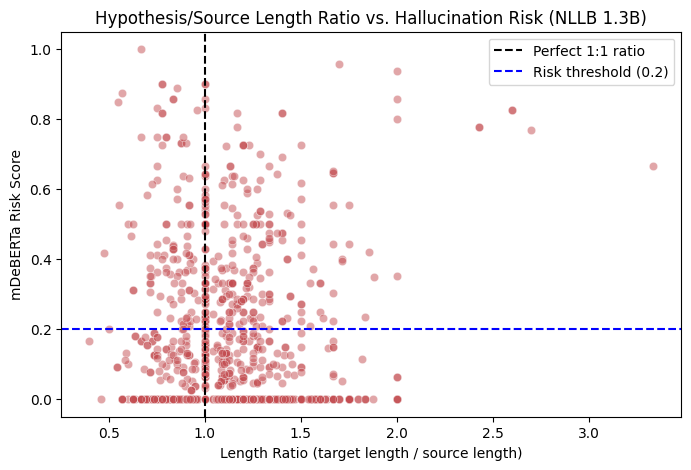

In [ ]:
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# Spearman correlation: log-prob confidence vs mDeBERTa risk 
print("SPEARMAN CORRELATION (Confidence vs. Risk)")
for m in models_to_test.keys():
    valid_mask  = eval_df_run[f'conf_{m}'] > -900  # exclude error sentinels
    conf_scores = eval_df_run.loc[valid_mask, f'conf_{m}']
    risk_scores = eval_df_run.loc[valid_mask, f'risk_{m}']
    corr, p_value = spearmanr(conf_scores, risk_scores)
    print(f"{m:15}: Correlation = {corr:.3f} (p-value: {p_value:.3e})")

# Length ratio analysis (NLLB 1.3B)
# Hypothesis length / source length. Extreme ratios (< 0.5 or > 2.0)
# often correlate with hallucinations or repetition errors.
print("\n--- LENGTH OSCILLATION ANALYSIS FOR NLLB 1.3B ---")
eval_df_run['src_len']             = eval_df_run['sinhala'].apply(lambda x: len(str(x).split()))
eval_df_run['hyp_len_nllb_1.3b']   = eval_df_run['hyp_nllb_1.3b'].apply(lambda x: len(str(x).split()))
eval_df_run['length_ratio_nllb']   = eval_df_run['hyp_len_nllb_1.3b'] / (eval_df_run['src_len'] + 1e-5)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=eval_df_run,
    x='length_ratio_nllb', y='risk_nllb_1.3b',
    alpha=0.5, color="#C44E52"
)
plt.axvline(x=1.0, color='black', linestyle='--', label="Perfect 1:1 ratio")
plt.axhline(y=0.20, color='blue',  linestyle='--', label="Risk threshold (0.2)")
plt.title("Hypothesis/Source Length Ratio vs. Hallucination Risk (NLLB 1.3B)")
plt.xlabel("Length Ratio (target length / source length)")
plt.ylabel("mDeBERTa Risk Score")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import spearmanr

# Sweep τ from 0.10 to 0.35 and record how many sentences get flagged at each level.
# Stable counts across consecutive τ values means the detector is robust.
# A sharp drop between two values reveals a sensitivity cliff worth noting.
print("── Risk Threshold (τ) Sensitivity Sweep ────────────────────────────")
print(f"{'Model':<15}  " + "  ".join(f"τ={t}" for t in THRESHOLD_SWEEP))
print("─" * 75)

sweep_records = []
for m in models_to_test.keys():
    col_risk = f'risk_{m}'
    if col_risk not in eval_df_run.columns:
        continue
    row_vals = []
    for tau in THRESHOLD_SWEEP:
        n_flagged = (eval_df_run[col_risk] > tau).sum()
        pct       = 100 * n_flagged / len(eval_df_run)
        row_vals.append(f"{n_flagged:>4} ({pct:4.1f}%)")
    print(f"{m:<15}  " + "  ".join(row_vals))
    sweep_records.append({
        "model": m,
        **{f"tau_{t}": (eval_df_run[col_risk] > t).sum() for t in THRESHOLD_SWEEP}
    })

print("\nInterpretation: stable counts across τ values indicate a robust detector.")
print("A sharp drop between two consecutive τ values reveals a sensitivity cliff.")

── Risk Threshold (τ) Sensitivity Sweep ────────────────────────────
Model            τ=0.1  τ=0.15  τ=0.2  τ=0.25  τ=0.3  τ=0.35
───────────────────────────────────────────────────────────────────────────
nllb_600m         430 (21.5%)   370 (18.5%)   311 (15.5%)   268 (13.4%)   237 (11.8%)   208 (10.4%)
m2m_1.2b          447 (22.3%)   374 (18.7%)   314 (15.7%)   264 (13.2%)   210 (10.5%)   177 ( 8.8%)
mt5_sin           995 (49.7%)   895 (44.7%)   802 (40.1%)   730 (36.5%)   659 (32.9%)   579 (28.9%)
mBART50           443 (22.1%)   365 (18.2%)   289 (14.4%)   234 (11.7%)   204 (10.2%)   168 ( 8.4%)
nllb_1.3b         480 (24.0%)   404 (20.2%)   347 (17.3%)   295 (14.7%)   252 (12.6%)   211 (10.5%)
opus_mul_en       781 (39.0%)   656 (32.8%)   571 (28.5%)   498 (24.9%)   444 (22.2%)   392 (19.6%)
m2m_418m          469 (23.4%)   396 (19.8%)   322 (16.1%)   269 (13.4%)   226 (11.3%)   188 ( 9.4%)
mbart_m2o         448 (22.4%)   381 (19.0%)   315 (15.7%)   252 (12.6%)   210 (10.5%)   172 ( 

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm


print("Loading LaBSE Model via Transformers for Cross-Lingual Similarity...")
tokenizer_labse = AutoTokenizer.from_pretrained("sentence-transformers/LaBSE")
model_labse     = AutoModel.from_pretrained("sentence-transformers/LaBSE").to(device)


def get_embeddings_transformers(texts, batch_size=16):
    """Encode texts with LaBSE and return L2-normalised mean-pooled embeddings."""
    model_labse.eval()
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting Embeddings"):
        batch_texts   = texts[i:i+batch_size]
        encoded_input = tokenizer_labse(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt',
            max_length=512
        ).to(device)

        with torch.no_grad():
            model_output = model_labse(**encoded_input)

        # Mean-pool over non-padding tokens
        attention_mask      = encoded_input['attention_mask']
        token_embeddings    = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings      = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask            = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        embeddings          = sum_embeddings / sum_mask
        embeddings          = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        all_embeddings.extend(embeddings.cpu().numpy())

    return all_embeddings


model_to_evaluate = 'nllb_1.3b' 

print(f"Encoding Sinhala source and {model_to_evaluate} hypothesis...")
sinhala_texts = eval_df_run['sinhala'].astype(str).tolist()
hyp_texts     = eval_df_run[f'hyp_{model_to_evaluate}'].astype(str).tolist()

src_embeddings = get_embeddings_transformers(sinhala_texts)
hyp_embeddings = get_embeddings_transformers(hyp_texts)

# Pairwise cosine similarity between each source and its hypothesis
similarities = [
    cosine_similarity([src], [hyp])[0][0]
    for src, hyp in zip(src_embeddings, hyp_embeddings)
]
eval_df_run[f'labse_sim_{model_to_evaluate}'] = similarities

hallucinations = eval_df_run[eval_df_run[f'risk_{model_to_evaluate}'] > 0.20]

print(
    f"\nAvg similarity — normal:        "
    f"{eval_df_run[eval_df_run[f'risk_{model_to_evaluate}'] <= 0.20][f'labse_sim_{model_to_evaluate}'].mean():.3f}"
)
print(
    f"Avg similarity — hallucinations: "
    f"{hallucinations[f'labse_sim_{model_to_evaluate}'].mean():.3f}"
)

# Severe cases: flagged by mDeBERTa AND very low cross-lingual similarity.
severe_hallucinations = hallucinations[
    hallucinations[f'labse_sim_{model_to_evaluate}'] < 0.3
]
print(f"\nFound {len(severe_hallucinations)} severe semantic disconnects.")
display(
    severe_hallucinations[[
        'sinhala',
        f'hyp_{model_to_evaluate}',
        f'risk_{model_to_evaluate}',
        f'labse_sim_{model_to_evaluate}'
    ]].head(10)
)

Loading LaBSE Model via Transformers for Cross-Lingual Similarity...
Encoding Sinhala source and nllb_1.3b hypothesis...


Extracting Embeddings:   0%|          | 0/126 [00:00<?, ?it/s]

Extracting Embeddings:   0%|          | 0/126 [00:00<?, ?it/s]


Avg similarity — normal:        0.907
Avg similarity — hallucinations: 0.863

Found 0 severe semantic disconnects.


,sinhala,hyp_nllb_1.3b,risk_nllb_1.3b,labse_sim_nllb_1.3b


## 10. Results & Visualisations

Build and display:

1. **Leaderboard table** — per-model flagging counts across all seven detection combinations
2. **Detection breakdown bar chart** — grouped bars showing which signal combinations fired for each model
3. **Average log-prob chart** — with per-model percentile threshold markers
4. **Confidence vs risk scatter plots** — one per model, with both detection thresholds overlaid


MODEL LEADERBOARD (percentile-based log-prob threshold)
  Log-prob: bottom 30.0th percentile per model
  mDeBERTa: risk rate > 0.2


,Model,Avg Log Prob,LogProb Thresh,All Three,mDeBERTa + LogProb,mDeBERTa + LaBSE,LogProb + LaBSE,mDeBERTa Only,LogProb Only,LaBSE Only,None
0,nllb_600m,-20.755089,-21.828222,19,95,12,11,185,474,19,1186
1,m2m_1.2b,-26.039945,-27.244495,34,81,21,22,178,463,38,1164
2,mt5_sin,-16.539746,-17.358042,284,132,141,56,245,127,97,919
3,mBART50,-18.695066,-19.985490,14,90,13,12,172,484,25,1191
4,nllb_1.3b,-21.627827,-22.769100,23,102,27,15,195,460,30,1149
5,opus_mul_en,-410.018352,-499.348899,97,58,232,61,184,292,390,687
6,m2m_418m,-25.829798,-27.471092,42,103,34,46,143,408,70,1155
7,mbart_m2o,-18.639900,-19.786128,11,88,18,8,198,493,22,1163



Detailed Samples (First 5 Rows):


,sinhala,reference,hyp_nllb_600m,conf_nllb_600m,risk_nllb_600m,lp_threshold_nllb_600m,flag_all_three_nllb_600m,flag_model_only_nllb_600m,flag_lp_only_nllb_600m,flag_none_nllb_600m,...,flag_lp_only_m2m_418m,flag_none_m2m_418m,hyp_mbart_m2o,conf_mbart_m2o,risk_mbart_m2o,lp_threshold_mbart_m2o,flag_all_three_mbart_m2o,flag_model_only_mbart_m2o,flag_lp_only_mbart_m2o,flag_none_mbart_m2o
0,"මීට අවුරුදු පහළොවකට පෙර, මම කතෝලික ප්‍රශංසාවේ ...","Fifteen years ago, I began my ministry as a le...","Fifteen years ago, I began my ministry as a le...",-16.086430,0.0,-21.828222,0,0,0,1,...,1,0,"Fifteen years ago, I began my ministry as a le...",-19.313975,0.0,-19.786128,0,0,0,1
1,ඔබගේ විප්ලවය තුල සාර්ථකයි.,succeeded in your revolution.,Successful in your revolution.,-17.685404,0.0,-21.828222,0,0,0,1,...,0,1,Success in your revolution.,-12.773136,0.0,-19.786128,0,0,0,1
2,"එපමණක් නොව එය තනිවම කළ හැකි බව, මම කිව යුතුයි,...","I must say, as well as it can be done alone, y...","Besides, you can do it alone, I must say, you'...",-26.552078,0.0,-21.828222,0,0,1,0,...,0,1,"If not that it can be done alone, I must say, ...",-23.018578,0.0,-19.786128,0,0,1,0
3,"[2.121] අප ග්‍රන්ථය ලබා දී ඇති අය, සහ එය කියවි...","[2.121] Those to whom We have given the Book, ...","Those to whom We have given the Book, and who ...",-28.296464,0.0,-21.828222,0,0,1,0,...,1,0,"Those who have given us the book, and those wh...",-23.662650,0.0,-19.786128,0,0,1,0
4,මොකද ළදරුවන් මධ්‍යම රාත්‍රියේ හෝ ඕනෑම වේලාවක අ...,Because babies start crying in the middle of t...,Because babies start crying at midnight or any...,-19.136120,0.0,-21.828222,0,0,0,1,...,0,1,Because babies start crying at midnight or any...,-16.580494,0.0,-19.786128,0,0,0,1


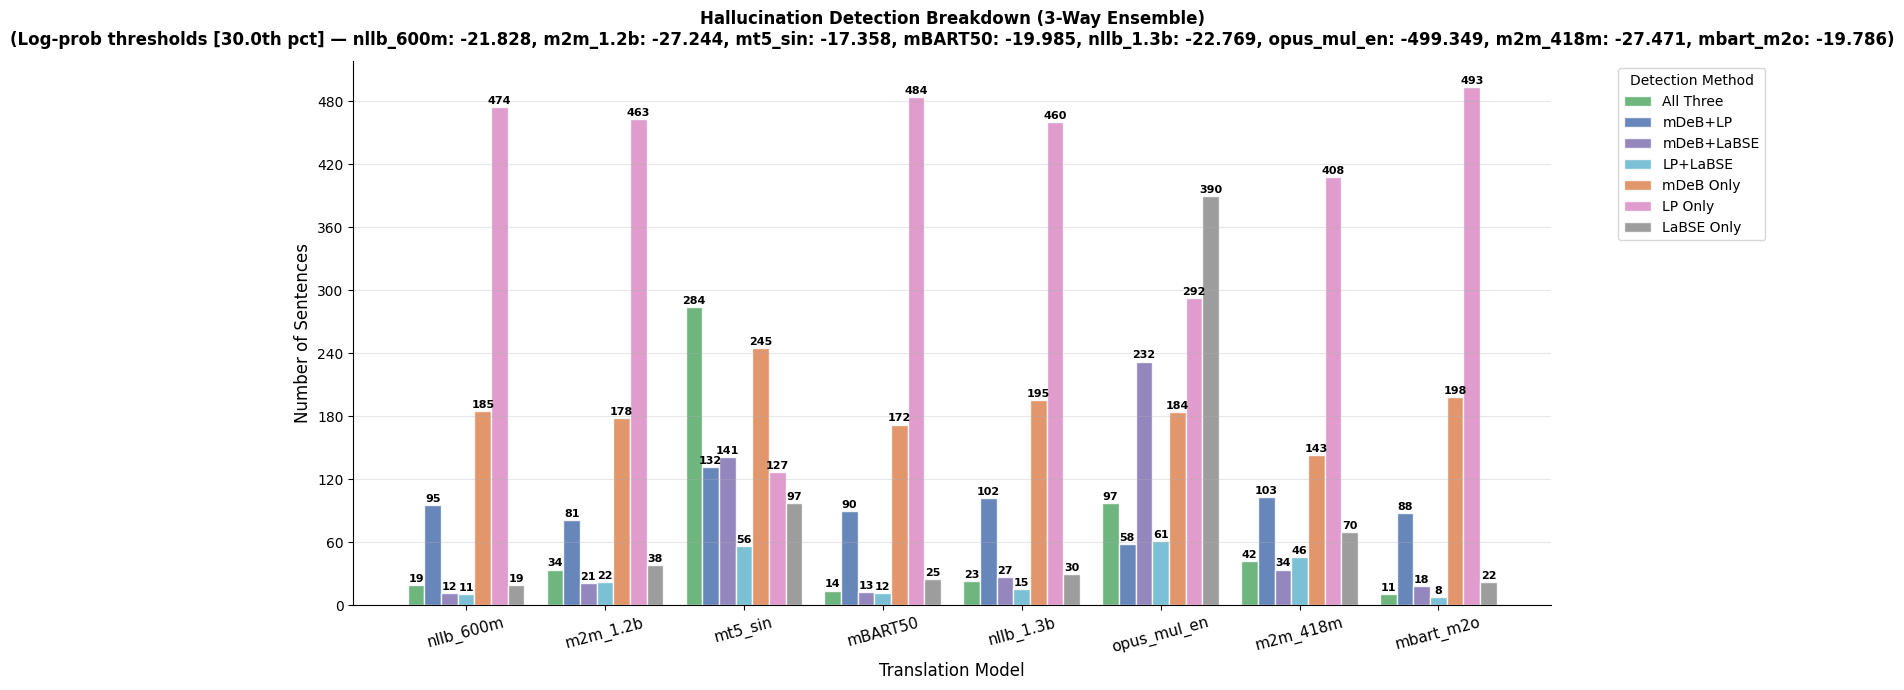

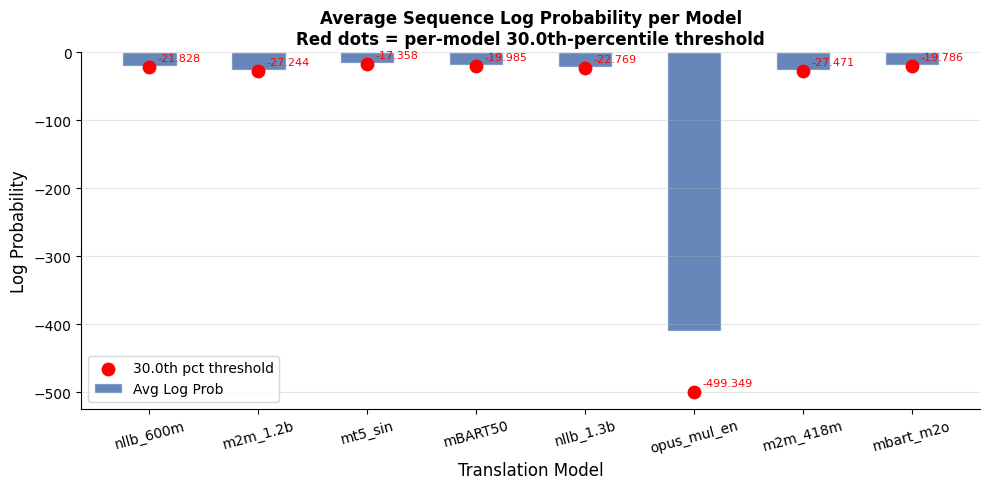

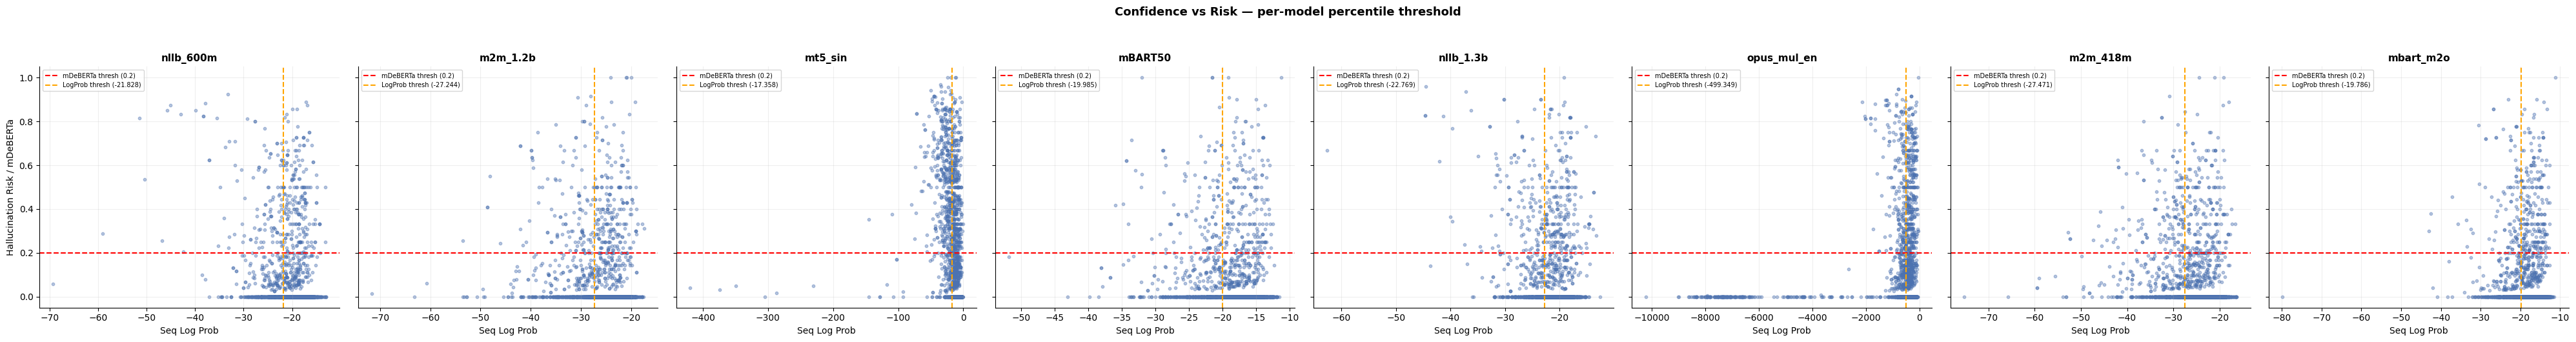

In [ ]:
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results_log)

# 1. Leaderboard
print("MODEL LEADERBOARD (percentile-based log-prob threshold)")
print(f"  Log-prob: bottom {LOGPROB_PERCENTILE}th percentile per model")
print(f"  mDeBERTa: risk rate > {RISK_THRESHOLD}")
display(results_df)

# 2. Detailed sample view 
cols_to_show = ['sinhala', 'reference']
for m in models_to_test.keys():
    cols_to_show += [
        f'hyp_{m}',
        f'conf_{m}',
        f'lp_threshold_{m}',
        f'risk_{m}',
        f'flag_model_only_{m}',
        f'flag_lp_only_{m}',
        f'flag_all_three_{m}',
        f'flag_none_{m}',
    ]
print("\nDetailed Samples (First 5 Rows):")
safe_cols = eval_df_run.columns.intersection(cols_to_show)
display(eval_df_run[safe_cols].head(5))

# 3. Detection method breakdown — stacked bar chart 
categories = ["All Three", "mDeB+LP", "mDeB+LaBSE", "LP+LaBSE",
               "mDeB Only", "LP Only", "LaBSE Only"]
cat_keys   = [
    "All Three", "mDeBERTa + LogProb", "mDeBERTa + LaBSE",
    "LogProb + LaBSE", "mDeBERTa Only", "LogProb Only", "LaBSE Only"
]
colors      = ["#55A868", "#4C72B0", "#8172B3", "#64B5CD",
               "#DD8452", "#DA8BC3", "#8C8C8C"]
model_names = results_df["Model"].tolist()
x     = np.arange(len(model_names))
width = 0.12

fig, ax = plt.subplots(figsize=(15, 7))
for i, (cat, key, color) in enumerate(zip(categories, cat_keys, colors)):
    counts = results_df[key].tolist()
    offset = (i - len(categories) / 2 + 0.5) * width
    bars   = ax.bar(x + offset, counts, width, label=cat,
                    color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2., h + 1,
            str(int(h)), ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

thresh_info = ", ".join(
    f"{row['Model']}: {row['LogProb Thresh']:.3f}"
    for _, row in results_df.iterrows()
)
ax.set_title(
    f"Hallucination Detection Breakdown (3-Way Ensemble)\n"
    f"(Log-prob thresholds [{LOGPROB_PERCENTILE}th pct] — {thresh_info})",
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel("Translation Model", fontsize=12)
ax.set_ylabel("Number of Sentences", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11, rotation=15)
ax.legend(title="Detection Method", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# 4. Average log-prob + per-model threshold 
avg_lps = results_df["Avg Log Prob"].tolist()
threshs = results_df["LogProb Thresh"].tolist()

fig2, ax2 = plt.subplots(figsize=(10, 5))
bars2 = ax2.bar(x, avg_lps, 0.5, color="#4C72B0", alpha=0.85,
                edgecolor='white', label="Avg Log Prob")
ax2.scatter(x, threshs, color='red', zorder=5, s=80,
            label=f"{LOGPROB_PERCENTILE}th pct threshold")

for xi, (avg, thr) in enumerate(zip(avg_lps, threshs)):
    ax2.annotate(f"{thr:.3f}", (xi, thr),
                 textcoords="offset points", xytext=(6, 4),
                 fontsize=8, color='red')
for bar, avg in zip(bars2, avg_lps):
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2., h - 0.04,
        f'{avg:.3f}', ha='center', va='top',
        fontsize=9, color='white', fontweight='bold'
    )
ax2.set_title(
    f"Average Sequence Log Probability per Model\n"
    f"Red dots = per-model {LOGPROB_PERCENTILE}th-percentile threshold",
    fontsize=12, fontweight='bold'
)
ax2.set_xlabel("Translation Model", fontsize=12)
ax2.set_ylabel("Log Probability", fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=15)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# 5. Confidence vs risk scatter 
fig3, axes = plt.subplots(
    1, len(models_to_test),
    figsize=(5 * len(models_to_test), 5),
    sharey=True
)
if len(models_to_test) == 1:
    axes = [axes]

for ax3, m in zip(axes, models_to_test.keys()):
    lp_thresh = eval_df_run[f'lp_threshold_{m}'].iloc[0]
    ax3.scatter(
        eval_df_run[f'conf_{m}'], eval_df_run[f'risk_{m}'],
        alpha=0.4, s=10, color="#4C72B0"
    )
    ax3.axhline(y=RISK_THRESHOLD, color='r', linestyle='--',
                label=f'mDeBERTa thresh ({RISK_THRESHOLD})')
    ax3.axvline(x=lp_thresh, color='orange', linestyle='--',
                label=f'LogProb thresh ({lp_thresh:.3f})')
    ax3.set_title(m, fontsize=11, fontweight='bold')
    ax3.set_xlabel("Seq Log Prob")
    ax3.legend(fontsize=7)
    ax3.grid(True, alpha=0.2)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

axes[0].set_ylabel("Hallucination Risk / mDeBERTa")
fig3.suptitle(
    "Confidence vs Risk — per-model percentile threshold",
    fontsize=13, fontweight='bold', y=1.05
)
plt.tight_layout()
plt.show()

## 11. Export

Save results to CSV and zip the trained mDeBERTa detector for download or later reuse.


In [20]:
# Save final results to CSV for external analysis or paper tables.
results_df.to_csv("resultspage.csv")
print("Results saved to resultspage.csv")

Results saved to resultspage.csv


In [ ]:
import shutil
from google.colab import files  # remove if not on Colab

# Zip the trained detector and download it.
shutil.make_archive("mdeberta_detector_archive", 'zip', "./mdeberta_detector")
print("Archive created: mdeberta_detector_archive.zip")

files.download("mdeberta_detector_archive.zip")

Archive created: mdeberta_detector_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>